In [1]:
import numpy as np
import matplotlib.pyplot as plt

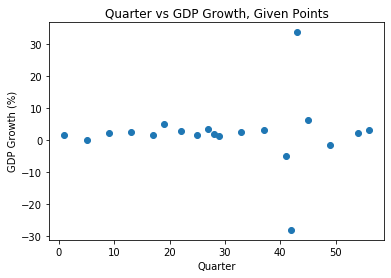

In [4]:
# create dataset, plot for checking

x = np.array([1,5,9,13,17,19,22,25,27,28,29,33,37,41,42,43,45,49,54,56])

y = np.array([1.7,0.1,2.3,2.7,1.7,5.0,3.0,1.5,3.5,1.8,1.3,2.5,3.1,-5.1,-28.1,33.8,6.3,-1.6,2.4,3.3])

plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.title("Quarter vs GDP Growth, Given Points")

plt.scatter(x,y, label = "Given Points")
plt.show()

In [5]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*(((y[i+1]-y[i])/h[i])-((y[i]-y[i-1])/h[i-1])) # Right-hand side vector
    return A, B, C, D

In [6]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        # Back substitution
    M = np.zeros(n)
    M[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        M[i] = (d[i] - c[i] * M[i+1]) / b[i]
    return M

In [7]:
A, B, C, D = setup_tridiagonal_matrix(x, y)

print("Subdiagonal (A):", A)
print("Main diagonal (B):", B)
print("Superdiagonal (C):", C)
print("Right-hand side (D):", D)

M = thomas_algorithm(A, B, C, D)
M = np.insert(M, 0, 0)
M = np.append(M, 0)
print("M ",M)

Subdiagonal (A): [4. 4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5.]
Main diagonal (B): [16. 16. 16. 12. 10. 12. 10.  6.  4. 10. 16. 16. 10.  4.  6. 12. 18. 14.]
Superdiagonal (C): [4. 4. 4. 2. 3. 3. 2. 1. 1. 4. 4. 4. 1. 1. 2. 4. 5. 2.]
Right-hand side (D): [   5.7    -2.7    -2.1    11.4   -13.9     1.      9.    -16.2     7.2
    4.8    -0.9   -13.2  -125.7   509.4  -453.9    70.65   16.65   -2.1 ]
M  [ 0.00000000e+00  3.95092366e-01 -1.55369464e-01 -4.48614511e-01
  1.42482751e+00 -1.95173602e+00 -2.73165986e-02  1.74375708e+00
 -4.17781049e+00  3.63559168e+00  1.01325424e+00 -2.24203352e+00
  8.48982050e+00 -3.50172485e+01  1.90513203e+02 -1.12583818e+02
  1.55448525e+01 -8.26102883e-01  8.60293952e-02  0.00000000e+00]


In [8]:
def evaluate_spline(M,x,y, xeval):
    n = len(x)
    h = np.diff(x)
    
    a = np.zeros(n)
    b = np.zeros(n)
    c = np.zeros(n)
    d = np.zeros(n)
    for i in range(0, n-1):
        a[i] = y[i]
        b[i] = ((y[i+1]-y[i])/h[i])-(h[i]/6)*(M[i+1]+2*M[i])
        c[i] = M[i]/2
        d[i] = (M[i+1]-M[i])/(6*h[i])
        

    start = np.searchsorted(x, xeval) - 1 # returns the interval index where wach value of xeval would be evaluated, so that each point gets the correct spline equation
    
    start[start<0] = 0
    start[start>(n-2)] = n-2
    # clips values so that anything below 0 = 0, anything above n-2 becomes n-2
    
    yeval = a[start] + b[start]*(xeval-x[start]) + c[start]*(xeval-x[start])**2 + d[start]*(xeval-x[start])**3
    # creates splines for each point
    return yeval
    

Text(0.5, 1.0, 'Quarter vs GDP Growth, Interpolated')

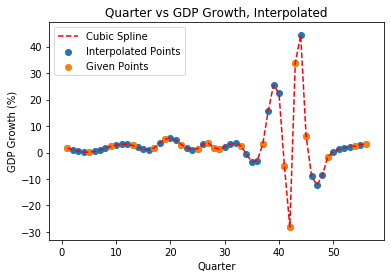

In [9]:
xeval = np.arange(1,57)
yeval = evaluate_spline(M,x,y,xeval)
plt.plot(xeval,yeval, 'r--', label = "Cubic Spline")
plt.scatter(xeval,yeval, label = "Interpolated Points")
plt.scatter(x,y, label = "Given Points")
plt.legend()
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.title("Quarter vs GDP Growth, Interpolated")



            4             3          2
-1.711e-06 x + 0.0003579 x - 0.0211 x + 0.4127 x + 0.2114


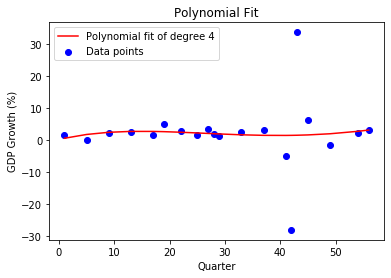

In [10]:
# Create Vandermonde matrix
degree = 4
V = np.vander(x, N=degree+1, increasing=True)

# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)

polynomial = np.poly1d(coefficients[::-1])

print(polynomial)

# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x)
# Step 4: Plotting the results
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('Quarter')
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.show()

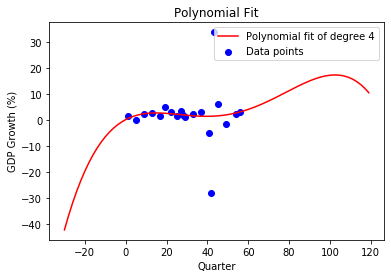

In [11]:
xnew = np.arange(-30,120)
y_pred2 = polynomial(xnew)
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(xnew, y_pred2, color='red', label=f'Polynomial fit of degree {degree}')
plt.title('Polynomial Fit')
plt.xlabel('Quarter')
plt.ylabel("GDP Growth (%)")
plt.legend()

In [12]:
def leastSquares(X,Y):
    sigX = np.sum(X)
    sigY = np.sum(Y)
    xSq = X**2
    sigX2 = np.sum(xSq)
    sigXY = np.dot(X,Y)
    n = len(X)
    
    m = (n*sigXY - sigX*sigY)/(n*sigX2 - sigX**2)
    c = (sigY - m*sigX)/n
    
    return m,c

[ 1.7  0.1  2.3  2.7  1.7  5.   3.   1.5  3.5  1.8  1.3  2.5  3.1 -1.6
  2.4  3.3]
Least Squares Slope: -0.00190698818897635, Least Squares Intercept: 2.194285187007873


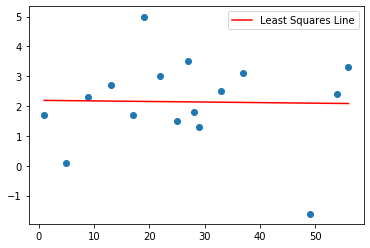

In [13]:
xnocovid = np.concatenate((x[:13], x[17:]))
ynocovid = np.concatenate((y[:13], y[17:]))


LSm, LSc = leastSquares(xnocovid,ynocovid)
print(f"Least Squares Slope: {LSm}, Least Squares Intercept: {LSc}")

plt.scatter(xnocovid,ynocovid)
plt.plot(xnocovid,LSm*xnocovid+LSc,'r', label = "Least Squares Line")
plt.legend()
plt.show()

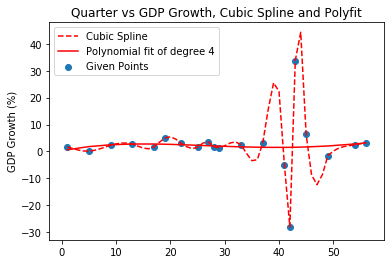

In [15]:
plt.plot(xeval,yeval, 'r--', label = "Cubic Spline")
plt.scatter(x,y, label = "Given Points")
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.title('Polynomial Fit')
plt.xlabel("")
plt.ylabel("GDP Growth (%)")
plt.title("Quarter vs GDP Growth, Cubic Spline and Polyfit")
plt.legend()
plt.show()